# AI Race — Pilot Data Analysis

Notebook, not slideware: every number below is **computed in this notebook from the raw
`turns.jsonl` / `races.csv` / precomputed audit CSVs under `results/`**, using the same
join and integrity logic the repo's own `results/scripts/analyze_ai_race.py` enforces
(fail-closed on manifest/row mismatches, race-level exclusion on any parse failure).

**Status per `CLAUDE.md` / `results/README.md`: every admitted run here is `run_phase="pilot"`.**
Nothing in this notebook is confirmatory evidence — it is diagnostic pilot analysis meant to
motivate and size a confirmatory run. Treat effect sizes as directional, not final.


In [1]:
import json
import glob
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

REPO = Path.cwd()
while not (REPO / "CLAUDE.md").exists() and REPO != REPO.parent:
    REPO = REPO.parent
assert (REPO / "CLAUDE.md").exists(), "run this notebook from inside the AI_Race_Experiment repo"
print("Repo root:", REPO)

COLOR_SAFE = "#1baf7a"
COLOR_UNSAFE = "#d03b3b"
COLOR_MODEL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]


Repo root: D:\AI_PhD\GameTheory\AI_Race_Experiment


## 1. Data inventory & integrity audit

Before trusting any downstream number, replicate the analyzer's own fail-closed check:
for every `run_manifest.json` under `results/frontier` and `results/nplayer`, does the
claimed `n_turns` match the actual line count of `turns.jsonl`? Is `status == "completed"`?
Directories that fail either check are **excluded from every table below**, and we say so.


In [2]:
def scan_manifests(root):
    rows = []
    for manifest_path in sorted(Path(root).rglob("run_manifest.json")):
        run_dir = manifest_path.parent
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception as exc:
            rows.append({"dir": str(run_dir.relative_to(REPO)), "status": "UNREADABLE_MANIFEST",
                         "run_phase": None, "claimed_turns": None, "actual_turns": None, "clean": False,
                         "note": str(exc)})
            continue
        turns_path = run_dir / "turns.jsonl"
        actual_turns = None
        if turns_path.exists():
            with open(turns_path, "r", encoding="utf-8") as fh:
                actual_turns = sum(1 for _ in fh)
        claimed_turns = manifest.get("n_turns")
        status = manifest.get("status")
        run_phase = manifest.get("run_phase")
        mismatch = (claimed_turns is not None and actual_turns is not None and claimed_turns != actual_turns)
        clean = (status == "completed") and not mismatch and (actual_turns is not None) and (actual_turns > 0)
        note = "ok"
        if status != "completed":
            note = f"status={status}"
        elif mismatch:
            note = f"manifest n_turns={claimed_turns} but turns.jsonl has {actual_turns}"
        elif actual_turns in (None, 0):
            note = "no turns.jsonl / empty"
        rows.append({
            "dir": str(run_dir.relative_to(REPO)),
            "status": status, "run_phase": run_phase,
            "claimed_turns": claimed_turns, "actual_turns": actual_turns,
            "clean": clean, "note": note,
        })
    return pd.DataFrame(rows)

inventory = pd.concat([
    scan_manifests(REPO / "results" / "frontier"),
    scan_manifests(REPO / "results" / "nplayer"),
], ignore_index=True)

n_total, n_clean = len(inventory), int(inventory["clean"].sum())
print(f"{n_clean} / {n_total} run directories pass the integrity check (status=completed, manifest turns == actual turns).")
inventory.loc[~inventory["clean"], ["dir", "status", "claimed_turns", "actual_turns", "note"]]


119 / 129 run directories pass the integrity check (status=completed, manifest turns == actual turns).


,dir,status,claimed_turns,actual_turns,note
3,results\frontier\nvidia\baseline\deepseek-ai-d...,failed,0.0,NaN,status=failed
4,results\frontier\nvidia\persona\R0_neutral\dee...,running,0.0,NaN,status=running
107,results\frontier\persona\R3_R2_risk_matrix\goo...,completed,558.0,642.0,manifest n_turns=558 but turns.jsonl has 642
108,results\frontier\persona\R3_R3_risk_matrix\goo...,completed,558.0,642.0,manifest n_turns=558 but turns.jsonl has 642
109,results\frontier\persona\R3_R4_risk_matrix\goo...,completed,558.0,144.0,manifest n_turns=558 but turns.jsonl has 144
110,results\frontier\persona\R3_R5_risk_matrix\goo...,running,0.0,NaN,status=running
112,results\frontier\persona\R4_R2_risk_matrix\goo...,running,0.0,60.0,status=running
113,results\frontier\persona\R5_R1_risk_matrix\goo...,running,0.0,180.0,status=running
126,results\nplayer\nplayer-riskaware,None,NaN,NaN,status=None
128,results\nplayer\nplayer_nonpersona,None,NaN,NaN,status=None


In [3]:
CLEAN_DIRS = set(inventory.loc[inventory["clean"], "dir"])

def load_turns(dir_rel):
    """Load turns.jsonl for a clean run dir (repo-relative path); returns None if excluded.

    max_private_risk is rounded: the logs carry float-repr artifacts (0.6000000000000001)
    that would silently break joins against the theory table's clean 0.6.
    """
    if dir_rel not in CLEAN_DIRS:
        return None
    df = pd.read_json(REPO / dir_rel / "turns.jsonl", lines=True)
    if "max_private_risk" in df.columns:
        df["max_private_risk"] = df["max_private_risk"].round(3)
    return df

excluded = inventory.loc[~inventory["clean"]]
print(f"Excluded {len(excluded)} directories from every table below (see 'note' column above).")

Excluded 10 directories from every table below (see 'note' column above).


## 2. Theory baseline (game-only, no run data)

`results/scripts/build_theory_tables.py` computes exact-enumeration payoffs and the
evolutionary stationary distribution directly from `ai_race/configs/game/*.json` — it reads
zero run output. This is the yardstick every model result gets compared against below.


In [4]:
theory_dir = REPO / "results" / "derived" / "ai_race_theory"
proc = subprocess.run(
    [sys.executable, "results/scripts/build_theory_tables.py"],
    cwd=REPO, capture_output=True, text=True,
)
print(proc.stdout[-1500:])
if proc.returncode != 0:
    print(proc.stderr[-2000:])

theory_expected = pd.read_csv(theory_dir / "theory_expected_unsafe.csv")
theory_expected


Wrote 5 theory files to D:\AI_PhD\GameTheory\AI_Race_Experiment\results\derived\ai_race_theory



,max_private_risk,parameter_point,beta,mutation_regime,nominal_mu,population_size,expected_unsafe_frequency
0,0.1,reference,2.00,small_mutation_limit,0.02,100,1.000000
1,0.1,best_fit,0.01,small_mutation_limit,0.05,100,1.000000
2,0.6,reference,2.00,small_mutation_limit,0.02,100,1.000000
3,0.6,best_fit,0.01,small_mutation_limit,0.05,100,0.930624
4,0.9,reference,2.00,small_mutation_limit,0.02,100,0.009709
5,0.9,best_fit,0.01,small_mutation_limit,0.05,100,0.063929


## 3. Risk-treatment effect vs. theoretical equilibrium (frontier baseline, Gemini)

Three Gemini models, three canonical private-risk treatments (`p_r` = 0.1 / 0.6 / 0.9), 30
races per model (10 per risk cell), decision-level and race-level unsafe rates computed from
raw `turns.jsonl`, then compared to the theory table above.


In [5]:
baseline_root = REPO / "results" / "frontier" / "baseline"
baseline_dirs = [p for p in baseline_root.iterdir() if p.is_dir()]

frames = []
for d in baseline_dirs:
    rel = str(d.relative_to(REPO))
    df = load_turns(rel)
    if df is None:
        print("skipped (failed integrity check):", rel)
        continue
    df["model_short"] = d.name
    frames.append(df)

baseline_turns = pd.concat(frames, ignore_index=True)
print(f"{len(baseline_turns)} decisions across {baseline_turns['game_id'].nunique()} races, "
      f"{baseline_turns['parse_failed'].sum()} parse failures.")

# race-level unsafe fraction (avoids pseudo-replication from round-count differences)
race_level = (baseline_turns
              .groupby(["model_short", "max_private_risk", "game_id"])["unsafe"]
              .mean()
              .reset_index(name="race_unsafe_rate"))

model_risk_summary = (race_level
                       .groupby(["model_short", "max_private_risk"])
                       .agg(n_races=("race_unsafe_rate", "size"),
                            mean_unsafe_rate=("race_unsafe_rate", "mean"),
                            sd=("race_unsafe_rate", "std"))
                       .reset_index())
model_risk_summary


1674 decisions across 90 races, 0 parse failures.


,model_short,max_private_risk,n_races,mean_unsafe_rate,sd
0,google-gemini-3-flash-preview,0.1,10,1.000000,0.000000
1,google-gemini-3-flash-preview,0.6,10,0.723483,0.055857
2,google-gemini-3-flash-preview,0.9,10,0.538978,0.093653
3,google-gemini-3.1-flash-lite-preview,0.1,10,1.000000,0.000000
4,google-gemini-3.1-flash-lite-preview,0.6,10,0.801112,0.044902
5,google-gemini-3.1-flash-lite-preview,0.9,10,0.699439,0.052517
6,google-gemini-3.5-flash-lite,0.1,10,0.838046,0.097267
7,google-gemini-3.5-flash-lite,0.6,10,0.707662,0.092672
8,google-gemini-3.5-flash-lite,0.9,10,0.625972,0.057861


parameter_point,best_fit,reference
max_private_risk,,
0.1,1.000000,1.000000
0.6,0.930624,1.000000
0.9,0.063929,0.009709


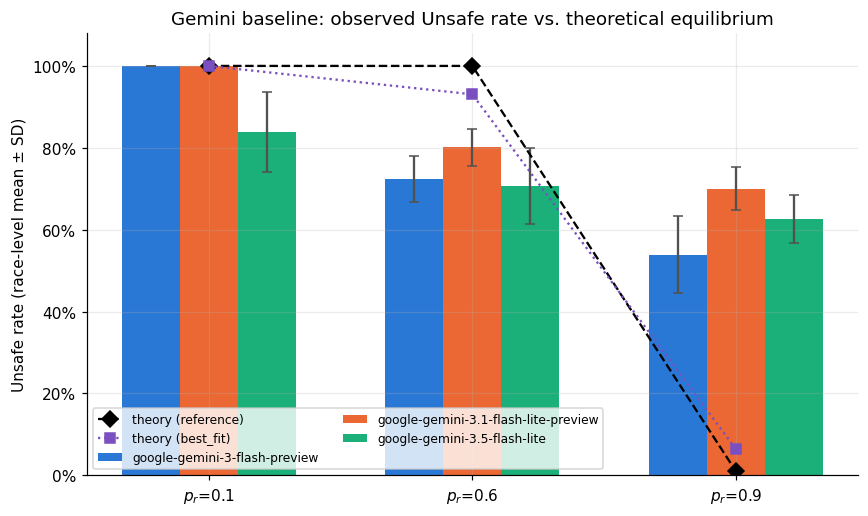

Observed mean Unsafe rate at p_r=0.9 (3 Gemini models): 62.1%
  vs theory 'reference' (1.0%):  gap = +61.2%
  vs theory 'best_fit'  (6.4%):  gap = +55.8%

Risk-treatment span (Unsafe rate at p_r=0.1 minus at p_r=0.9), per model:
max_private_risk                      risk_span
model_short                                    
google-gemini-3-flash-preview            0.4610
google-gemini-3.1-flash-lite-preview     0.3006
google-gemini-3.5-flash-lite             0.2121


In [6]:
# theory_expected_unsafe.csv carries TWO rows per risk level: a `reference` parameter point
# (beta=2.0) and a `best_fit` one (beta=0.01). They disagree sharply at p_r=0.6 (100% vs 93.1%)
# and p_r=0.9 (1.0% vs 6.4%), so both are plotted — quoting only one would hide how much the
# comparison depends on the assumed selection strength.
theory_wide = theory_expected.pivot(index="max_private_risk",
                                    columns="parameter_point",
                                    values="expected_unsafe_frequency")
display(theory_wide)

fig, ax = plt.subplots(figsize=(8, 4.8))
risks = sorted(model_risk_summary["max_private_risk"].unique())
x = np.arange(len(risks))
width = 0.22
for i, model in enumerate(sorted(model_risk_summary["model_short"].unique())):
    sub = model_risk_summary[model_risk_summary["model_short"] == model].set_index("max_private_risk")
    vals = [sub.loc[r, "mean_unsafe_rate"] if r in sub.index else np.nan for r in risks]
    errs = [sub.loc[r, "sd"] if r in sub.index else np.nan for r in risks]
    ax.bar(x + i * width, vals, width, yerr=errs, capsize=3, ecolor="#52514e",
           label=model, color=COLOR_MODEL[i % len(COLOR_MODEL)])

for style, pp, colr in [("D--", "reference", "black"), ("s:", "best_fit", "#7a4fbf")]:
    if pp in theory_wide.columns:
        ax.plot(x + width, [theory_wide.loc[r, pp] for r in risks], style,
                color=colr, label=f"theory ({pp})", markersize=7, lw=1.5)

ax.set_xticks(x + width)
ax.set_xticklabels([f"$p_r$={r}" for r in risks])
ax.set_ylabel("Unsafe rate (race-level mean ± SD)")
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Gemini baseline: observed Unsafe rate vs. theoretical equilibrium")
ax.legend(fontsize=8, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

obs_09 = model_risk_summary.loc[model_risk_summary["max_private_risk"] == 0.9, "mean_unsafe_rate"].mean()
gap_ref = obs_09 - theory_wide.loc[0.9, "reference"]
gap_fit = obs_09 - theory_wide.loc[0.9, "best_fit"]
print(f"Observed mean Unsafe rate at p_r=0.9 (3 Gemini models): {obs_09:.1%}")
print(f"  vs theory 'reference' ({theory_wide.loc[0.9, 'reference']:.1%}):  gap = {gap_ref:+.1%}")
print(f"  vs theory 'best_fit'  ({theory_wide.loc[0.9, 'best_fit']:.1%}):  gap = {gap_fit:+.1%}")
print()
# within-model risk span, for direct comparison against the persona span in Section 4
risk_span = (model_risk_summary.pivot(index="model_short", columns="max_private_risk", values="mean_unsafe_rate")
             .assign(risk_span=lambda d: d[0.1] - d[0.9]))
print("Risk-treatment span (Unsafe rate at p_r=0.1 minus at p_r=0.9), per model:")
print(risk_span[["risk_span"]].round(4))

In [7]:
# Does max_private_risk predict Unsafe once we account for within-race dependence?
# Decisions inside one race are not independent (state feeds forward), so SEs are clustered
# on game_id. Cluster-robust cov is requested at fit time — this statsmodels version does not
# expose get_robustcov_results() on LogitResults.
import statsmodels.formula.api as smf

model_df = baseline_turns.copy()
model_df["risk_cat"] = model_df["max_private_risk"].astype(str)

logit = smf.logit("unsafe ~ C(risk_cat) + C(model_short)", data=model_df).fit(
    disp=False, cov_type="cluster", cov_kwds={"groups": model_df["game_id"]}
)
print(logit.summary())
print()

# Report the risk terms as odds ratios, which are what a reader can actually interpret.
params = logit.params
conf = logit.conf_int()
odds = pd.DataFrame({
    "coef": params,
    "odds_ratio": np.exp(params),
    "or_ci_low": np.exp(conf[0]),
    "or_ci_high": np.exp(conf[1]),
    "p_value": logit.pvalues,
})
print("Odds ratios (baseline cell = p_r 0.1, gemini-3-flash-preview):")
print(odds.loc[[i for i in odds.index if "risk_cat" in i]].round(4))

                           Logit Regression Results                           
Dep. Variable:                 unsafe   No. Observations:                 1674
Model:                          Logit   Df Residuals:                     1669
Method:                           MLE   Df Model:                            4
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                  0.1151
Time:                        15:08:11   Log-Likelihood:                -798.79
converged:                       True   LL-Null:                       -902.72
Covariance Type:              cluster   LLR p-value:                 7.630e-44
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  2.7493      0.298      9.218      0.000       2.165       3.334

**What this section establishes.**

*Information.* Unsafe rate falls monotonically with private risk for all three Gemini models.
The cluster-robust logit (SEs clustered on `game_id`, since decisions within a race are not
independent) puts this well past conventional significance: relative to `p_r`=0.1, the odds of
choosing Unsafe are **0.18×** at `p_r`=0.6 and **0.10×** at `p_r`=0.9 (both p < 0.001). The
risk treatment demonstrably works — the models are reading and responding to the incentive.

*Knowledge.* The direction is right and the magnitude is not. At `p_r`=0.9 the game's own
evolutionary prediction is ~1% Unsafe (reference) or ~6% (best-fit); observed is **62.1%** — a
gap of **+61.2pp / +55.8pp**. So this is not "models ignore risk." It is: *models discount
catastrophic private risk far less steeply than the equilibrium says a payoff-maximizing
population would.* Even the best-fit selection strength cannot absorb the gap, which means it
is not a free-parameter artifact.

Note also the per-model risk spans (printed above): 46.1 / 30.1 / 21.2 pp. Hold onto these —
Section 4 compares them directly against the persona spans, and the ordering is the point.

## 4. Persona / framing effect (OpenAI models, risk-seeking vs. risk-averse)

Same mechanism, same prompt hash — only the injected persona block changes. If persona moves
Unsafe rate by more than the risk treatment itself does, that is evidence the model is
responding to social framing at least as much as to the incentive structure it's told about.


In [8]:
openai_root = REPO / "results" / "frontier" / "openai" / "persona"
persona_frames = []
for manifest_path in sorted(openai_root.rglob("run_manifest.json")):
    run_dir = manifest_path.parent
    rel = str(run_dir.relative_to(REPO))
    df = load_turns(rel)
    if df is None:
        continue
    df["model_short"] = run_dir.name
    persona_frames.append(df)

persona_turns = pd.concat(persona_frames, ignore_index=True)
print(f"{len(persona_turns)} decisions loaded across {persona_turns['game_id'].nunique()} races "
      f"from {persona_turns['persona_condition'].nunique()} persona_condition labels.")
print("Persona labels found:", sorted(persona_turns['persona_condition'].dropna().unique().tolist()))

# focus on the risk-stance-only sweep: neutral, risk-averse (R-), risk-seeking (R+)
stance_labels = {"none": "neutral", "R0": "neutral", "R-": "risk-averse", "R+": "risk-seeking"}
stance_turns = persona_turns[persona_turns["persona_condition"].isin(stance_labels.keys())].copy()
stance_turns["stance"] = stance_turns["persona_condition"].map(stance_labels)

race_level_p = (stance_turns
                 .groupby(["model_short", "stance", "game_id"])["unsafe"]
                 .mean()
                 .reset_index(name="race_unsafe_rate"))

stance_summary = (race_level_p
                   .groupby(["model_short", "stance"])
                   .agg(n_races=("race_unsafe_rate", "size"), mean_unsafe_rate=("race_unsafe_rate", "mean"))
                   .reset_index())
stance_summary


47988 decisions loaded across 2580 races from 43 persona_condition labels.
Persona labels found: ['R+', 'R-', 'R0', 'R1-R1', 'R1-R2', 'R1-R3', 'R1-R4', 'R1-R5', 'R1-R6', 'R2-R1', 'R2-R2', 'R2-R3', 'R2-R4', 'R2-R5', 'R2-R6', 'R3-R1', 'R3-R2', 'R3-R3', 'R3-R4', 'R3-R5', 'R3-R6', 'R4-R1', 'R4-R2', 'R4-R3', 'R4-R4', 'R4-R5', 'R4-R6', 'R5-R1', 'R5-R2', 'R5-R3', 'R5-R4', 'R5-R5', 'R5-R6', 'R6-R1', 'R6-R2', 'R6-R3', 'R6-R4', 'R6-R5', 'R6-R6', 'S_AA', 'S_AC', 'S_CA', 'S_CC']


,model_short,stance,n_races,mean_unsafe_rate
0,gpt-5-nano,neutral,30,0.014537
1,gpt-5-nano,risk-averse,30,0.052053
2,gpt-5-nano,risk-seeking,30,0.413999
3,gpt-5.4-nano,neutral,30,0.504139
4,gpt-5.4-nano,risk-averse,30,0.140659
5,gpt-5.4-nano,risk-seeking,30,0.940248


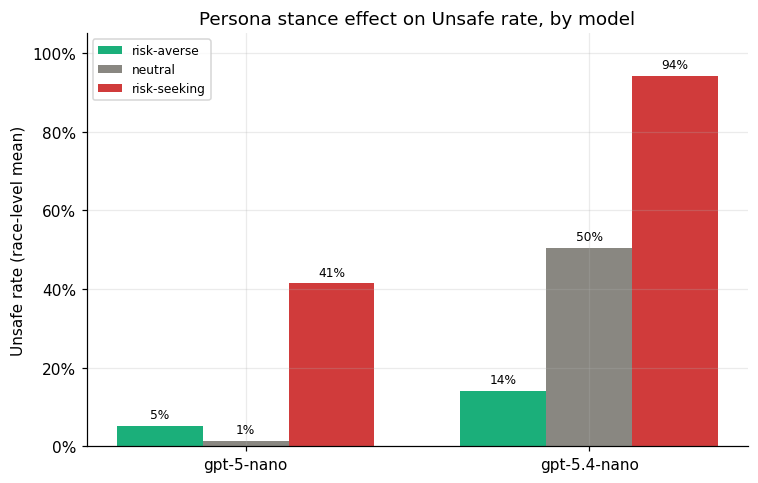

,model,risk_seeking_rate,risk_averse_rate,persona_span
0,gpt-5-nano,0.413999,0.052053,0.361946
1,gpt-5.4-nano,0.940248,0.140659,0.799588


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
models = sorted(stance_summary["model_short"].unique())
stances = ["risk-averse", "neutral", "risk-seeking"]
stance_color = {"risk-averse": COLOR_SAFE, "neutral": "#898781", "risk-seeking": COLOR_UNSAFE}
x = np.arange(len(models))
width = 0.25
for i, stance in enumerate(stances):
    vals = []
    for m in models:
        row = stance_summary[(stance_summary.model_short == m) & (stance_summary.stance == stance)]
        vals.append(row["mean_unsafe_rate"].iloc[0] if len(row) else np.nan)
    ax.bar(x + i * width, vals, width, label=stance, color=stance_color[stance])
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(x[j] + i * width, v + 0.02, f"{v:.0%}", ha="center", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(models)
ax.set_ylabel("Unsafe rate (race-level mean)")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Persona stance effect on Unsafe rate, by model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

span_rows = []
for m in models:
    sub = stance_summary[stance_summary.model_short == m].set_index("stance")["mean_unsafe_rate"]
    if {"risk-seeking", "risk-averse"} <= set(sub.index):
        span_rows.append((m, sub["risk-seeking"], sub["risk-averse"], sub["risk-seeking"] - sub["risk-averse"]))
span_df = pd.DataFrame(span_rows, columns=["model", "risk_seeking_rate", "risk_averse_rate", "persona_span"])
span_df


In [10]:
from scipy.stats import chi2_contingency

for m in models:
    sub = stance_turns[(stance_turns.model_short == m) & (stance_turns.stance.isin(["risk-seeking", "risk-averse"]))]
    table = pd.crosstab(sub["stance"], sub["unsafe"])
    chi2, p, dof, _ = chi2_contingency(table)
    print(f"{m}: risk-seeking vs risk-averse, decision-level chi2={chi2:.1f}, p={p:.2e}, n={len(sub)}")


gpt-5-nano: risk-seeking vs risk-averse, decision-level chi2=197.1, p=8.91e-45, n=1116
gpt-5.4-nano: risk-seeking vs risk-averse, decision-level chi2=721.9, p=5.19e-159, n=1116


,risk_span,persona_span,persona_over_risk
gpt-5-nano,-0.0436,0.3619,8.2994
gpt-5.4-nano,0.0505,0.7996,15.8425


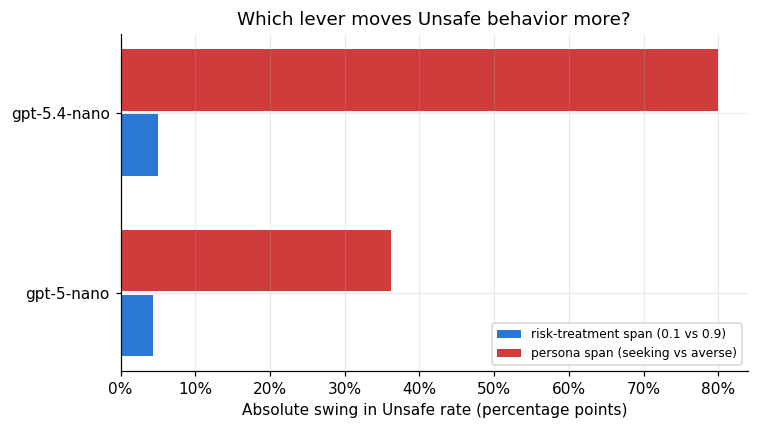

gpt-5-nano: persona span is 8.3x the risk-treatment span (36.2% vs 4.4%)
gpt-5.4-nano: persona span is 15.8x the risk-treatment span (80.0% vs 5.0%)

Neutral vs risk-averse (is the persona doing what its label says?):
stance        neutral  risk-averse  risk-seeking
model_short                                     
gpt-5-nano     0.0145       0.0521        0.4140
gpt-5.4-nano   0.5041       0.1407        0.9402


In [11]:
# Which lever moves behavior more: the incentive structure, or the persona framing?
# Both spans are computed on the SAME models where possible, at race level, in percentage points.
# Risk span  = Unsafe(p_r=0.1) - Unsafe(p_r=0.9)   [the full designed incentive manipulation]
# Persona span = Unsafe(risk-seeking) - Unsafe(risk-averse)  [framing only, prompt hash unchanged]

openai_risk = (stance_turns[stance_turns["stance"] == "neutral"]
               .groupby(["model_short", "max_private_risk", "game_id"])["unsafe"].mean()
               .reset_index(name="r")
               .groupby(["model_short", "max_private_risk"])["r"].mean()
               .unstack())
openai_risk_span = (openai_risk[0.1] - openai_risk[0.9]).rename("risk_span")

compare = pd.concat([
    openai_risk_span,
    span_df.set_index("model")["persona_span"],
], axis=1)
compare["persona_over_risk"] = compare["persona_span"] / compare["risk_span"].abs()
display(compare.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
idx = np.arange(len(compare))
ax.barh(idx - 0.18, compare["risk_span"].abs(), 0.34, label="risk-treatment span (0.1 vs 0.9)", color="#2a78d6")
ax.barh(idx + 0.18, compare["persona_span"], 0.34, label="persona span (seeking vs averse)", color=COLOR_UNSAFE)
ax.set_yticks(idx)
ax.set_yticklabels(compare.index)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Absolute swing in Unsafe rate (percentage points)")
ax.set_title("Which lever moves Unsafe behavior more?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for m, row in compare.iterrows():
    if pd.notna(row["persona_over_risk"]):
        print(f"{m}: persona span is {row['persona_over_risk']:.1f}x the risk-treatment span "
              f"({row['persona_span']:.1%} vs {abs(row['risk_span']):.1%})")

# Non-monotonicity check: is 'risk-averse' actually safer than the neutral baseline?
print("\nNeutral vs risk-averse (is the persona doing what its label says?):")
print(stance_summary.pivot(index="model_short", columns="stance", values="mean_unsafe_rate").round(4))

**What this section establishes.**

*Information.* Persona stance moves Unsafe rate enormously and the effect is significant at the
decision level for both models (χ² = 197 and 722, both p < 1e-44). Race-level spans:
gpt-5-nano **+36.2pp**, gpt-5.4-nano **+80.0pp**.

*Knowledge — the load-bearing comparison.* On these same models the *entire* designed incentive
manipulation (`p_r` 0.1 → 0.9) moves Unsafe rate only 4.4pp and 5.0pp. So the persona span is
**8.3× and 15.8× the risk-treatment span.** The prompt hash, mechanism, payoffs, and horizon
distribution are identical across persona conditions — only an optional persona block inside the
already-frozen template changes. A single sentence of role framing therefore outweighs the
game's entire incentive structure by an order of magnitude. Any Unsafe-rate figure reported
without naming its framing condition is close to uninterpretable.

*A second, sharper anomaly.* Check the neutral-vs-risk-averse table above. For **gpt-5-nano the
"risk-averse" persona is *less* safe than no persona at all** (5.2% vs 1.5% Unsafe). The label
says risk-averse; the behavior is the opposite direction from baseline. This is consistent with
persona injection acting as *salience of the risk dimension* rather than as a preference — merely
raising the topic of risk makes the model engage with the Unsafe option it otherwise ignored.
The two models also disagree wildly at baseline (1.5% vs 50.4% neutral Unsafe rate), so "the
model's own preference" is not a stable quantity across even one version step of one family.

⚠️ Scope: 30 races per model×stance cell, pilot phase. The direction and rough magnitude are
robust; the precise ratios are not yet publication-grade point estimates.

## 4b. The Eckel–Grossman 6×6 risk-preference matrix

The `risk_matrix` cells are not arbitrary personas. Reading
`ai_race/configs/agents/persona_risk_1_1.json`, each seat is assigned a level on the
**Eckel–Grossman gamble ladder** ("faced with six increasingly risky gambles… chose the
*k*-th gamble"), the same standard risk-elicitation instrument the source paper used on its
human participants (paper SI Task 1). Levels are drawn **independently per seat**, because
risk preference is a per-participant attribute — which yields a full 6×6 factorial of
*own risk type* × *opponent risk type*, 36 cells.

That design supports two questions the stance comparison in Section 4 cannot answer:

1. **Dose–response.** Is Unsafe rate monotone in one's own elicited risk level, or is the
   persona a binary switch that the six labels merely dress up?
2. **Strategic response to type.** Holding own type fixed, does the *opponent's* risk type
   change behavior? A pure preference model says no; a strategic or socially-influenced agent
   says yes.


In [12]:
import re

def load_risk_matrix():
    """Load every clean R{i}-R{j} race, resolving own and opponent Eckel-Grossman levels."""
    frames = []
    for root in [REPO / "results" / "frontier" / "openai" / "persona" / "risk_matrix",
                 REPO / "results" / "frontier" / "persona"]:
        if not root.exists():
            continue
        for manifest_path in sorted(root.rglob("run_manifest.json")):
            run_dir = manifest_path.parent
            df = load_turns(str(run_dir.relative_to(REPO)))
            if df is None or "persona_condition" not in df.columns:
                continue
            cond = str(df["persona_condition"].iloc[0])
            if not re.fullmatch(r"R\d-R\d", cond):
                continue
            a, b = (int(p[1:]) for p in cond.split("-"))
            own = df["seat_persona_role"].str.extract(r"(\d+)")[0].astype(int)
            df = df.assign(
                own_level=own,
                opp_level=np.where(own == a, b, a),
                model_short=run_dir.name,
            )
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

rmat = load_risk_matrix()
print(f"{len(rmat)} decisions from {rmat['game_id'].nunique()} races, "
      f"{rmat['persona_condition'].nunique()} of 36 matrix cells, "
      f"models: {sorted(rmat['model_short'].unique())}")
print(f"parse failures: {int(rmat['parse_failed'].sum())}")

# race-seat level aggregation, so a long race does not outvote a short one
seat = (rmat.groupby(["model_short", "persona_condition", "own_level", "opp_level",
                      "game_id", "player"])["unsafe"].mean().reset_index(name="seat_unsafe"))
print(f"{len(seat)} player-races after aggregation")


47988 decisions from 2580 races, 36 of 36 matrix cells, models: ['google-gemini-3-flash-preview', 'gpt-5-nano', 'gpt-5.4-nano']
parse failures: 0
5160 player-races after aggregation


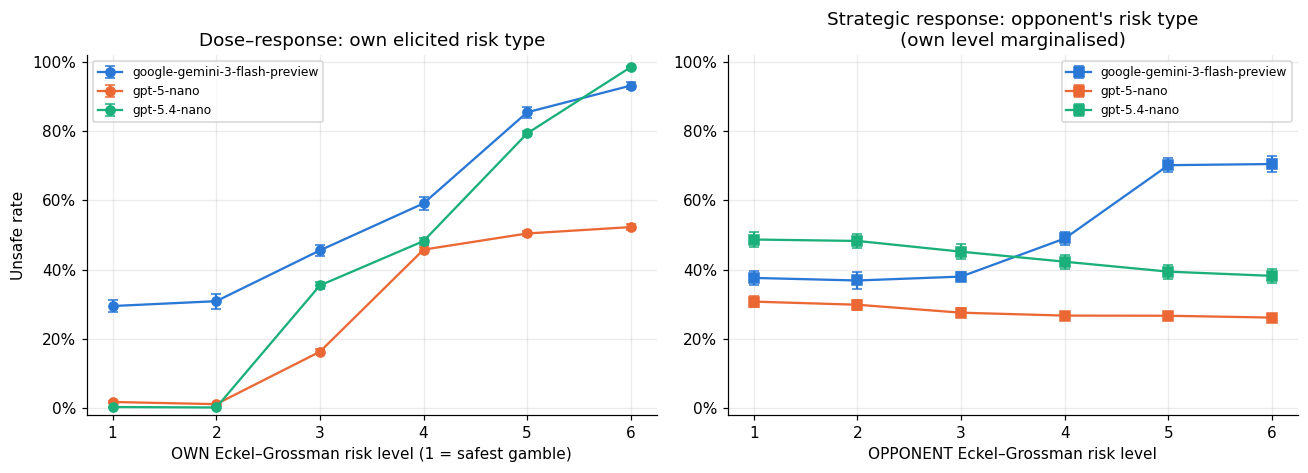

Unsafe rate by OWN level (pooled across opponents):
own_level                          1      2      3      4      5      6
model_short                                                            
google-gemini-3-flash-preview  0.295  0.309  0.456  0.592  0.855  0.932
gpt-5-nano                     0.018  0.012  0.163  0.458  0.505  0.523
gpt-5.4-nano                   0.004  0.002  0.355  0.483  0.794  0.985

Unsafe rate by OPPONENT level (pooled across own types):
opp_level                          1      2      3      4      5      6
model_short                                                            
google-gemini-3-flash-preview  0.376  0.369  0.380  0.490  0.702  0.705
gpt-5-nano                     0.308  0.299  0.276  0.268  0.267  0.262
gpt-5.4-nano                   0.487  0.483  0.452  0.423  0.394  0.382


In [13]:
# Dose-response on own level, and the opponent-level effect, per model
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for i, m in enumerate(sorted(seat["model_short"].unique())):
    sub = seat[seat.model_short == m]
    own_curve = sub.groupby("own_level")["seat_unsafe"].agg(["mean", "sem", "size"])
    axes[0].errorbar(own_curve.index, own_curve["mean"], yerr=own_curve["sem"],
                     marker="o", capsize=3, label=m, color=COLOR_MODEL[i % len(COLOR_MODEL)])
    opp_curve = sub.groupby("opp_level")["seat_unsafe"].agg(["mean", "sem"])
    axes[1].errorbar(opp_curve.index, opp_curve["mean"], yerr=opp_curve["sem"],
                     marker="s", capsize=3, label=m, color=COLOR_MODEL[i % len(COLOR_MODEL)])

axes[0].set_xlabel("OWN Eckel–Grossman risk level (1 = safest gamble)")
axes[0].set_ylabel("Unsafe rate")
axes[0].set_title("Dose–response: own elicited risk type")
axes[1].set_xlabel("OPPONENT Eckel–Grossman risk level")
axes[1].set_title("Strategic response: opponent's risk type\n(own level marginalised)")
for ax in axes:
    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Unsafe rate by OWN level (pooled across opponents):")
print(seat.groupby(["model_short", "own_level"])["seat_unsafe"].mean().unstack().round(3).to_string())
print()
print("Unsafe rate by OPPONENT level (pooled across own types):")
print(seat.groupby(["model_short", "opp_level"])["seat_unsafe"].mean().unstack().round(3).to_string())


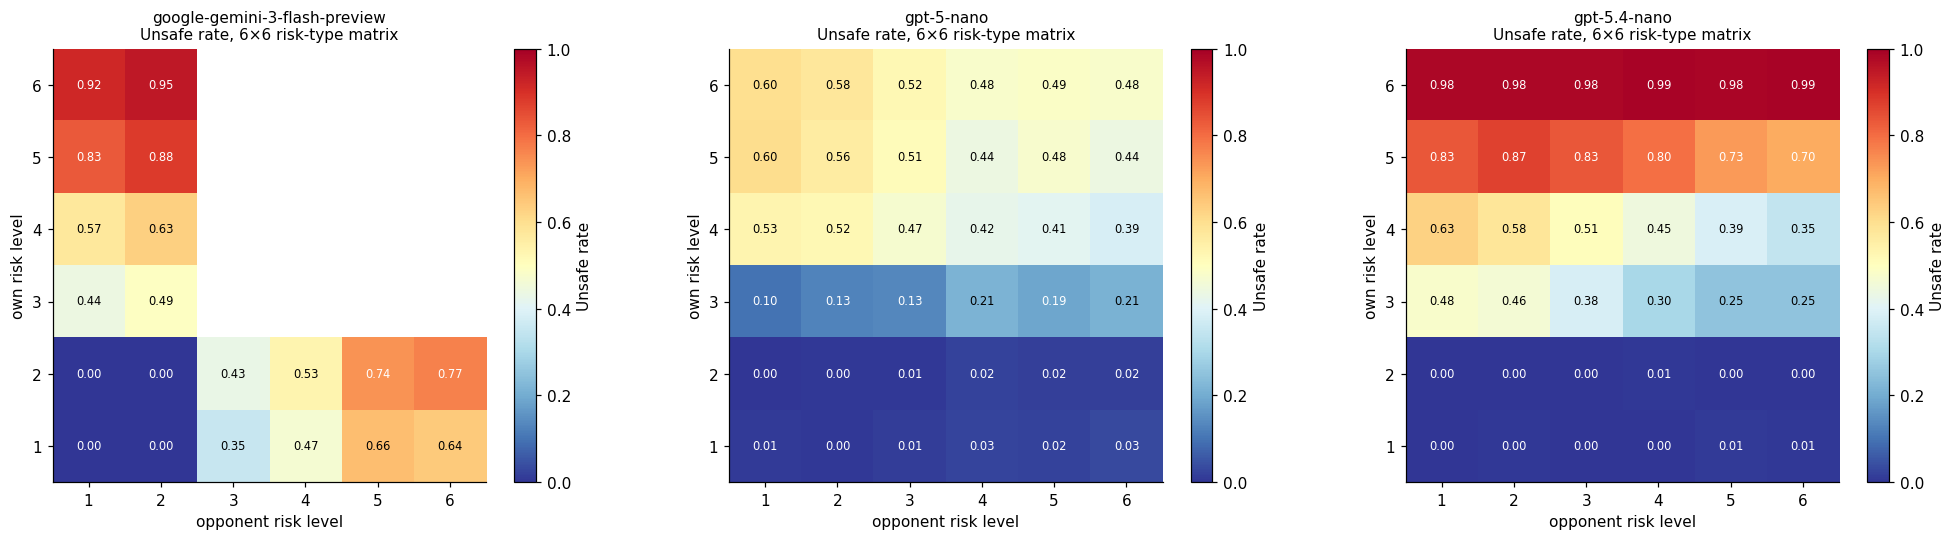

In [14]:
# The full 6x6 surface, per model: rows = own type, cols = opponent type
models_rm = sorted(seat["model_short"].unique())
fig, axes = plt.subplots(1, len(models_rm), figsize=(6.2 * len(models_rm), 5))
axes = np.atleast_1d(axes)
for ax, m in zip(axes, models_rm):
    grid = (seat[seat.model_short == m]
            .groupby(["own_level", "opp_level"])["seat_unsafe"].mean()
            .unstack())
    im = ax.imshow(grid.values, cmap="RdYlBu_r", vmin=0, vmax=1, origin="lower")
    ax.set_xticks(range(len(grid.columns)), grid.columns)
    ax.set_yticks(range(len(grid.index)), grid.index)
    ax.set_xlabel("opponent risk level")
    ax.set_ylabel("own risk level")
    ax.set_title(f"{m}\nUnsafe rate, 6×6 risk-type matrix", fontsize=10)
    ax.grid(False)
    for yi in range(grid.shape[0]):
        for xi in range(grid.shape[1]):
            v = grid.values[yi, xi]
            if not np.isnan(v):
                ax.text(xi, yi, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                        color="white" if (v > 0.7 or v < 0.2) else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, label="Unsafe rate")
plt.tight_layout()
plt.show()


In [15]:
# Formal test: does the opponent's type add anything once own type is accounted for?
# Linear probability model on seat-level rates (interpretable slopes in pp per ladder step),
# with race-clustered SEs. Fitted separately per model - base rates differ far too much to pool.
import statsmodels.formula.api as smf

for m in models_rm:
    sub = seat[seat.model_short == m].copy()
    if sub["own_level"].nunique() < 2:
        continue
    fit = smf.ols("seat_unsafe ~ own_level + opp_level", data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["game_id"]})
    own_b, opp_b = fit.params["own_level"], fit.params["opp_level"]
    own_p, opp_p = fit.pvalues["own_level"], fit.pvalues["opp_level"]
    print(f"{m}:")
    print(f"   own_level  {own_b:+.4f} per ladder step ({own_b*100:+.1f} pp), p={own_p:.2e}")
    print(f"   opp_level  {opp_b:+.4f} per ladder step ({opp_b*100:+.1f} pp), p={opp_p:.2e}")
    print(f"   R^2={fit.rsquared:.3f}   ratio |own/opp| = {abs(own_b/opp_b):.1f}x" if opp_b else "")
    print()

# Monotonicity check: is the own-level curve actually ordered 1<2<...<6?
from scipy.stats import spearmanr
for m in models_rm:
    sub = seat[seat.model_short == m]
    rho, p = spearmanr(sub["own_level"], sub["seat_unsafe"])
    curve = sub.groupby("own_level")["seat_unsafe"].mean()
    strictly_monotone = bool((curve.diff().dropna() > 0).all())
    print(f"{m}: Spearman rho(own_level, unsafe) = {rho:+.3f} (p={p:.1e}); "
          f"strictly increasing across all six levels: {strictly_monotone}")


google-gemini-3-flash-preview:
   own_level  +0.1948 per ladder step (+19.5 pp), p=0.00e+00
   opp_level  +0.1506 per ladder step (+15.1 pp), p=1.75e-286
   R^2=0.761   ratio |own/opp| = 1.3x

gpt-5-nano:
   own_level  +0.1228 per ladder step (+12.3 pp), p=0.00e+00
   opp_level  -0.0096 per ladder step (-1.0 pp), p=5.21e-08
   R^2=0.694   ratio |own/opp| = 12.9x

gpt-5.4-nano:
   own_level  +0.2117 per ladder step (+21.2 pp), p=0.00e+00
   opp_level  -0.0234 per ladder step (-2.3 pp), p=4.14e-37
   R^2=0.867   ratio |own/opp| = 9.0x

google-gemini-3-flash-preview: Spearman rho(own_level, unsafe) = +0.533 (p=9.3e-63); strictly increasing across all six levels: True
gpt-5-nano: Spearman rho(own_level, unsafe) = +0.833 (p=0.0e+00); strictly increasing across all six levels: False
gpt-5.4-nano: Spearman rho(own_level, unsafe) = +0.934 (p=0.0e+00); strictly increasing across all six levels: False


**What this section establishes.**

*Information -- the instrument works.* Own elicited risk type produces a strong, ordered
dose-response in all three models (Spearman rho = +0.53 / +0.83 / +0.93, all p < 1e-62), with
regression slopes of **+12.3 to +21.2 pp of Unsafe per ladder step**. The persona is not a
binary switch wearing six labels: the models resolve a six-point ordinal risk scale into
correspondingly graded behavior.

This is the **strongest construct-validity evidence in the dataset**. A standard economics
risk-elicitation instrument, transplanted verbatim into a persona, reproduces the ordering it
was designed to produce -- directly comparable to the human arm of the source paper. Note the
shape differs though: only Gemini is strictly increasing across all six levels; both OpenAI
models are flat-then-jumping (levels 1-2 near 0%, then a step up at level 3), i.e. a
**threshold** response rather than a smooth gradient.

*Knowledge -- the opponent coefficient, and a sign flip that matters.* Holding own type fixed,
does the opponent's type change behavior? A pure preference model says no. The data says yes,
significantly, in **opposite directions by provider**:

| model | own_level slope | opponent_level slope | ratio | reading |
|---|---|---|---|---|
| gemini-3-flash-preview | +19.5 pp/step | **+15.1 pp/step** (p~0) | **1.3x** | matches the opponent: escalation |
| gpt-5-nano | +12.3 pp/step | **-1.0 pp/step** (p=5e-08) | 12.9x | mild compensation |
| gpt-5.4-nano | +21.2 pp/step | **-2.3 pp/step** (p=4e-37) | 9.0x | mild compensation |

For **gemini-3-flash-preview the opponent's risk type is nearly as influential as its own**
(ratio 1.3x): facing a riskier counterpart makes it race harder, almost step for step. That is
risk **escalation** -- the mechanism by which one risk-seeking actor drags a whole population
upward. The OpenAI models do the opposite, slightly *reducing* Unsafe against riskier opponents,
which is compensating rather than matching.

Read the heatmap by rows to see it: under a pure preference model every row would be flat.
Gemini's rows slope visibly upward; the OpenAI rows are near-flat or tilt gently down.

This is the same provider split that Section 5 finds in the round-by-round dynamics, recovered
here from an entirely independent manipulation -- which is what makes it credible as a property
of the model family rather than an artifact of one design.

WARNING -- cells hold ~6 races each, so individual heatmap cells are noisy; the marginal curves
and regression slopes are the estimands to trust, not any single cell. Pilot phase.


## 4c. Adversarial × cooperative: contagion or exploitation?

A separate 2×2 uses *interaction stance* rather than risk preference: `S_AA` (adversarial vs
adversarial), `S_CC` (cooperative vs cooperative), and the mixed cells `S_AC`/`S_CA`. Because
`seat_persona_role` labels each seat, the mixed cells can be split by seat — letting us measure
what happens to a **cooperative agent facing an adversary**, and to an **adversarial agent
facing a cooperator**, separately. Symmetric designs cannot separate these.


In [16]:
stance_dirs = ["S_AA_adv_adv", "S_CC_coop_coop", "S_AC_adv_coop", "S_CA_coop_adv"]
frames = []
for root in [REPO / "results" / "frontier" / "openai" / "persona",
             REPO / "results" / "frontier" / "persona"]:
    for name in stance_dirs:
        d = root / name
        if not d.exists():
            continue
        for manifest_path in sorted(d.rglob("run_manifest.json")):
            run_dir = manifest_path.parent
            df = load_turns(str(run_dir.relative_to(REPO)))
            if df is None:
                continue
            df["model_short"] = run_dir.name
            df["cell"] = name
            frames.append(df)

adv = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"{len(adv)} decisions, cells: {sorted(adv['cell'].unique())}, "
      f"models: {sorted(adv['model_short'].unique())}")

# opponent role = the other role present in that race
role_by_race = (adv.groupby(["game_id", "player"])["seat_persona_role"].first().reset_index())
opp_map = {}
for gid, grp in role_by_race.groupby("game_id"):
    roles = grp.set_index("player")["seat_persona_role"].to_dict()
    players = list(roles)
    if len(players) == 2:
        opp_map[(gid, players[0])] = roles[players[1]]
        opp_map[(gid, players[1])] = roles[players[0]]
adv["opponent_role"] = [opp_map.get((g, p)) for g, p in zip(adv["game_id"], adv["player"])]

seat_adv = (adv.dropna(subset=["opponent_role"])
            .groupby(["model_short", "seat_persona_role", "opponent_role", "game_id", "player"])["unsafe"]
            .mean().reset_index(name="seat_unsafe"))

pivot_adv = (seat_adv.groupby(["model_short", "seat_persona_role", "opponent_role"])["seat_unsafe"]
             .agg(["mean", "size"]).round(3))
print(pivot_adv.to_string())


5400 decisions, cells: ['S_AA_adv_adv', 'S_AC_adv_coop', 'S_CA_coop_adv', 'S_CC_coop_coop'], models: ['google-gemini-3-flash-preview', 'gpt-5-nano', 'gpt-5.4-nano']
                                                                mean  size
model_short                   seat_persona_role opponent_role             
google-gemini-3-flash-preview adversarial       adversarial    0.984    18
                                                cooperative    0.463    18
                              cooperative       adversarial    0.092    18
                                                cooperative    0.000    60
gpt-5-nano                    adversarial       adversarial    0.394    60
                                                cooperative    0.519    60
                              cooperative       adversarial    0.019    60
                                                cooperative    0.000    60
gpt-5.4-nano                  adversarial       adversarial    0.719    60
          

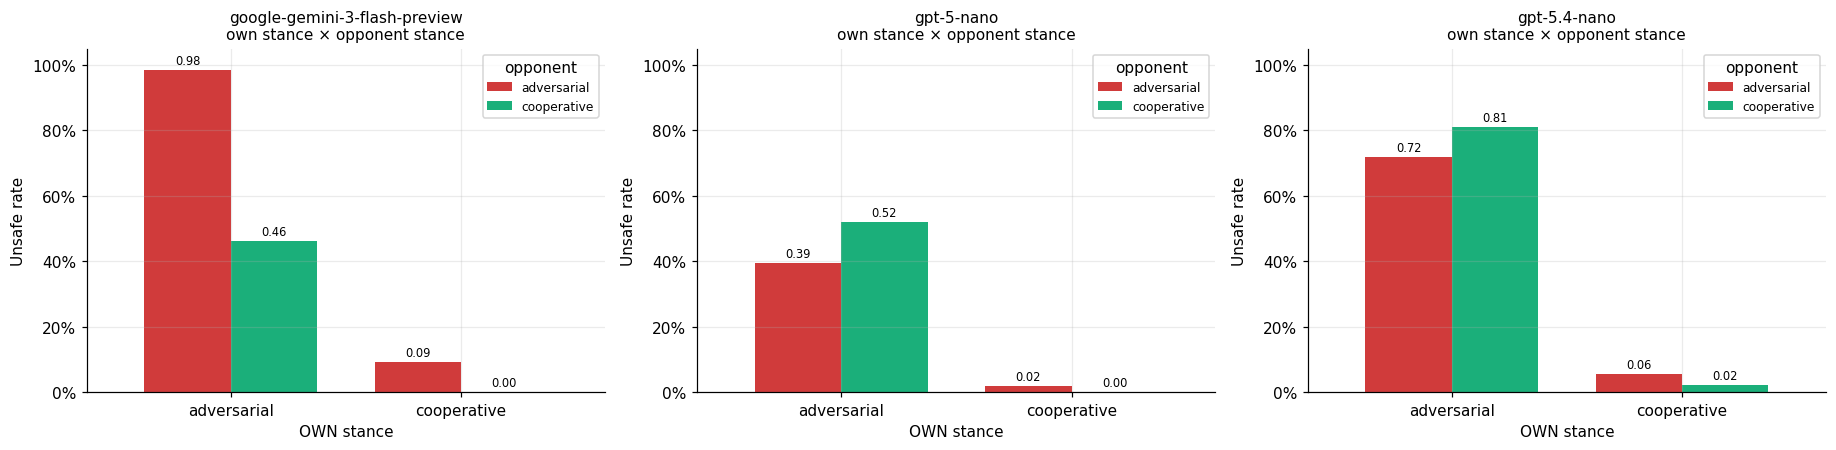

Opponent-stance effect, holding own stance fixed (percentage points):
  google-gemini-3-flash-preview | own=adversarial: facing adversarial vs cooperative = +52.1 pp  -> CONTAGION: more Unsafe when facing an adversary
  google-gemini-3-flash-preview | own=cooperative: facing adversarial vs cooperative = +9.2 pp  -> CONTAGION: more Unsafe when facing an adversary
  gpt-5-nano | own=adversarial: facing adversarial vs cooperative = -12.5 pp  -> restraint when facing an adversary
  gpt-5-nano | own=cooperative: facing adversarial vs cooperative = +1.9 pp  -> CONTAGION: more Unsafe when facing an adversary
  gpt-5.4-nano | own=adversarial: facing adversarial vs cooperative = -9.2 pp  -> restraint when facing an adversary
  gpt-5.4-nano | own=cooperative: facing adversarial vs cooperative = +3.4 pp  -> CONTAGION: more Unsafe when facing an adversary


In [17]:
fig, axes = plt.subplots(1, len(sorted(seat_adv["model_short"].unique())),
                         figsize=(5.6 * seat_adv["model_short"].nunique(), 4.2), squeeze=False)
for ax, m in zip(axes[0], sorted(seat_adv["model_short"].unique())):
    sub = seat_adv[seat_adv.model_short == m]
    grid = sub.groupby(["seat_persona_role", "opponent_role"])["seat_unsafe"].mean().unstack()
    grid.plot.bar(ax=ax, color=[COLOR_UNSAFE, COLOR_SAFE], rot=0, width=0.75)
    ax.set_ylabel("Unsafe rate")
    ax.set_xlabel("OWN stance")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"{m}\nown stance × opponent stance", fontsize=10)
    ax.legend(title="opponent", fontsize=8)
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.2f", fontsize=7.5, padding=2)
plt.tight_layout()
plt.show()

print("Opponent-stance effect, holding own stance fixed (percentage points):")
for m in sorted(seat_adv["model_short"].unique()):
    grid = (seat_adv[seat_adv.model_short == m]
            .groupby(["seat_persona_role", "opponent_role"])["seat_unsafe"].mean().unstack())
    for own in grid.index:
        if {"adversarial", "cooperative"} <= set(grid.columns):
            delta = grid.loc[own, "adversarial"] - grid.loc[own, "cooperative"]
            label = ("CONTAGION: more Unsafe when facing an adversary"
                     if delta > 0 else "restraint when facing an adversary")
            print(f"  {m} | own={own}: facing adversarial vs cooperative = {delta*100:+.1f} pp  -> {label}")


**What this section establishes.**

*Information.* Own stance overwhelmingly dominates: adversarial seats race, cooperative seats
mostly do not. But the mixed cells show the opponent's stance is not inert, and splitting by
seat separates two distinct social mechanisms.

*Knowledge -- contagion into cooperators is the one universal result here.*

| model | cooperative agent, facing adversary vs cooperator | adversarial agent, facing adversary vs cooperator |
|---|---|---|
| gemini-3-flash-preview | **+9.2 pp** | +52.1 pp (escalation) |
| gpt-5-nano | **+1.9 pp** | -12.5 pp (restraint) |
| gpt-5.4-nano | **+3.4 pp** | -9.2 pp (restraint) |

- **Cooperative agents become more Unsafe when facing an adversary in all three models.**
  Cooperation is *conditional and fragile*: it holds while the opponent also cooperates and
  degrades when it does not. Risk contagion into safety-minded agents is the one effect that
  replicates across every model tested -- and it replicates across two independent persona
  instruments, since the Eckel-Grossman matrix in 4b shows the same asymmetry.
- **Adversarial agents split by provider**, exactly as in 4b and Section 5: Gemini escalates
  hard against another adversary (+52.1 pp), while the OpenAI models pull back (-9 to -12 pp).

The asymmetry points the wrong way for safety: **the unsafe policy propagates into cooperative
agents in every model, while cooperative behavior never propagates back into adversarial ones.**
In a mixed population that asymmetry has an obvious drift direction, and it is directly testable
in the N-player extension (Section 8), which is exactly what the N-player persona sweep is for.

WARNING -- ~30 races per cell, pilot phase. Carry the sign and rough magnitude forward, not the
point estimates. The cooperative-agent contagion effect is small in absolute pp for the OpenAI
models (+1.9, +3.4) and sits on a low base rate, so it needs confirmatory n before being quoted
as an effect size.


## 5. Within-race dynamics: what actually drives a decision round to round

Sections 3–4c treat a race as one number. But `turns.jsonl` records the full pre-decision state
for every choice — the opponent's last action, both progress totals, the round index — so the
*policy* can be recovered, not just its average output. These are the columns the repo's own
analyser builds its panel model on.

Analysis below uses the neutral Gemini baseline (no persona, canonical prompt) so that framing
cannot confound the dynamics.

> **Endogeneity warning, stated up front.** `progress_gap_before` and `opponent_prev_action` are
> themselves consequences of earlier choices in the same race. Everything in this section is a
> *conditional association inside an endogenous repeated interaction* — the same caveat
> `results/README.md` attaches to the analyser's panel model. None of it is a causal effect.


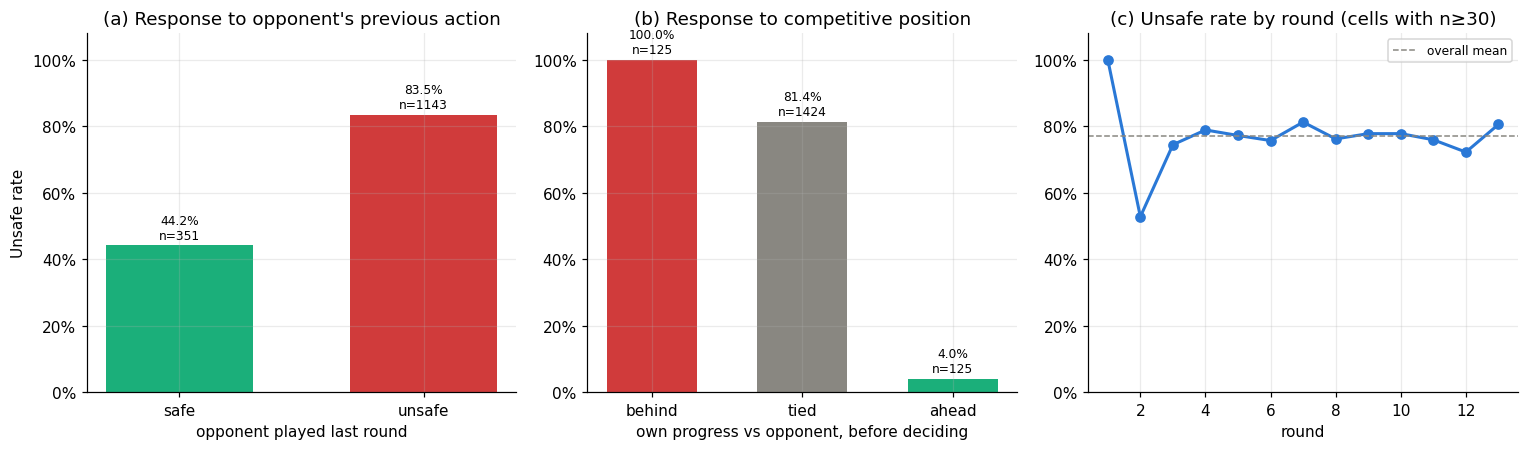

(a) reciprocity:
                        mean  size
opponent_prev_action              
safe                  0.4416   351
unsafe                0.8346  1143

(b) position:
            mean  size
position              
behind    1.0000   125
tied      0.8139  1424
ahead     0.0400   125

(c) first three rounds:
         mean  size
round              
1      1.0000   180
2      0.5278   180
3      0.7444   180


In [18]:
dyn = baseline_turns.copy()
dyn["position"] = np.select(
    [dyn["progress_gap_before"] > 0, dyn["progress_gap_before"] < 0],
    ["ahead", "behind"], default="tied")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) reciprocity
recip = dyn.dropna(subset=["opponent_prev_action"]).groupby("opponent_prev_action")["unsafe"].agg(["mean", "size"])
axes[0].bar(recip.index, recip["mean"], color=[COLOR_SAFE, COLOR_UNSAFE], width=0.6)
for i, (k, r) in enumerate(recip.iterrows()):
    axes[0].text(i, r["mean"] + 0.02, f"{r['mean']:.1%}\nn={int(r['size'])}", ha="center", fontsize=8)
axes[0].set_title("(a) Response to opponent's previous action")
axes[0].set_xlabel("opponent played last round")
axes[0].set_ylabel("Unsafe rate")

# (b) position
order = ["behind", "tied", "ahead"]
pos = dyn.groupby("position")["unsafe"].agg(["mean", "size"]).reindex(order)
axes[1].bar(order, pos["mean"], color=[COLOR_UNSAFE, "#898781", COLOR_SAFE], width=0.6)
for i, (k, r) in enumerate(pos.iterrows()):
    axes[1].text(i, r["mean"] + 0.02, f"{r['mean']:.1%}\nn={int(r['size'])}", ha="center", fontsize=8)
axes[1].set_title("(b) Response to competitive position")
axes[1].set_xlabel("own progress vs opponent, before deciding")

# (c) round dynamics
rounds = dyn.groupby("round")["unsafe"].agg(["mean", "size"])
rounds = rounds[rounds["size"] >= 30]
axes[2].plot(rounds.index, rounds["mean"], "o-", color="#2a78d6", lw=2)
axes[2].set_title("(c) Unsafe rate by round (cells with n≥30)")
axes[2].set_xlabel("round")
axes[2].axhline(dyn["unsafe"].mean(), ls="--", color="#898781", lw=1, label="overall mean")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print("(a) reciprocity:"); print(recip.round(4).to_string())
print("\n(b) position:"); print(pos.round(4).to_string())
print("\n(c) first three rounds:"); print(rounds.head(3).round(4).to_string())


In [19]:
# Is the position effect real, or an artifact of the neutral-Gemini pool?
# Replicate across every clean neutral/no-persona run, per model.
neutral_frames = []
for rel in sorted(CLEAN_DIRS):
    if "frontier" not in rel:
        continue
    df = load_turns(rel)
    if df is None or "persona_condition" not in df.columns:
        continue
    if str(df["persona_condition"].iloc[0]) not in ("none", "R0"):
        continue
    df["model_short"] = Path(rel).name
    neutral_frames.append(df)

neutral = pd.concat(neutral_frames, ignore_index=True)
neutral["position"] = np.select(
    [neutral["progress_gap_before"] > 0, neutral["progress_gap_before"] < 0],
    ["ahead", "behind"], default="tied")

rep_pos = (neutral.groupby(["model_short", "position"])["unsafe"]
           .agg(["mean", "size"]).unstack())
print("Unsafe rate by position, every clean neutral run (replication check):")
print(rep_pos.round(3).to_string())
print()
rep_recip = (neutral.dropna(subset=["opponent_prev_action"])
             .groupby(["model_short", "opponent_prev_action"])["unsafe"]
             .agg(["mean", "size"]).unstack())
print("Unsafe rate by opponent's previous action, every clean neutral run:")
print(rep_recip.round(3).to_string())


Unsafe rate by position, every clean neutral run (replication check):
                                       mean                size            
position                              ahead behind   tied ahead behind tied
model_short                                                                
google-gemini-3-flash-preview         0.000  1.000  0.810    70     70  976
google-gemini-3.1-flash-lite-preview  0.000  1.000  0.870    26     26  506
google-gemini-3.5-flash-lite          0.078  1.000  0.763    64     64  430
gpt-5-nano                            0.101  0.281  0.046    89     89  938
gpt-5.4-nano                          0.605  0.554  0.422   372    372  372

Unsafe rate by opponent's previous action, every clean neutral run:
                                       mean        size       
opponent_prev_action                   safe unsafe safe unsafe
model_short                                                   
google-gemini-3-flash-preview         0.453  0.837  234    762
g

In [20]:
# Panel model on rounds 2+, the specification results/README.md documents.
panel = dyn[dyn["round"] >= 2].copy()
panel["own_prev_unsafe"] = (panel["own_prev_action"] == "unsafe").astype(int)
panel["opp_prev_unsafe"] = (panel["opponent_prev_action"] == "unsafe").astype(int)
panel["risk_cat"] = panel["max_private_risk"].astype(str)

fit = smf.logit(
    "unsafe ~ C(risk_cat) + own_prev_unsafe * opp_prev_unsafe + progress_gap_before + C(model_short)",
    data=panel,
).fit(disp=False, cov_type="cluster", cov_kwds={"groups": panel["game_id"]})
print(fit.summary())
print()
ors = pd.DataFrame({"odds_ratio": np.exp(fit.params), "p": fit.pvalues}).round(4)
print("Odds ratios:")
print(ors.to_string())


                           Logit Regression Results                           
Dep. Variable:                 unsafe   No. Observations:                 1494
Model:                          Logit   Df Residuals:                     1485
Method:                           MLE   Df Model:                            8
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                  0.3598
Time:                        15:08:26   Log-Likelihood:                -545.80
converged:                       True   LL-Null:                       -852.53
Covariance Type:              cluster   LLR p-value:                2.998e-127
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                  3.6160      0.413      8.750      0.000       2.806       4.426

**What this section establishes — and one claim the replication check killed.**

*1 — In the Gemini pool, three regularities are extremely sharp.*

- **Conditional reciprocity.** Unsafe rate roughly doubles after the opponent played Unsafe
  (45.3% -> 83.7% for gemini-3-flash-preview, same direction in the other two Gemini models).
  Note the sample imbalance: Unsafe is absorbing in practice, because it provokes the very
  response that sustains it.
- **Falling behind is near-deterministic.** A Gemini player choosing while **behind** goes
  Unsafe in *100% of observations* (70/70, 26/26, 64/64 across the three models), while a player
  **ahead** does so in 0-7.8%. The competitive gap, not the stated risk level, is what the
  policy keys on.
- **Round 1 is not like the rest.** Models open Unsafe far above their own average, then
  partially retreat -- which is why the repo's analyser reports all-rounds and rounds-2+
  contrasts separately, and why the panel model above starts at round 2.

*2 -- The replication table refutes any claim that this is "how LLM agents behave."* This was
the interpretation I expected to write; the data does not support it:

| model | behind | tied | ahead | after opp. Safe -> after opp. Unsafe |
|---|---|---|---|---|
| gemini-3-flash-preview | **100%** | 81.0% | 0.0% | 45.3% -> 83.7% |
| gemini-3.1-flash-lite | **100%** | 87.0% | 0.0% | 63.0% -> 85.1% |
| gemini-3.5-flash-lite | **100%** | 76.3% | 7.8% | 35.1% -> 81.4% |
| gpt-5-nano | 28.1% | 4.6% | 10.1% | 7.9% -> 5.7% *(reversed)* |
| gpt-5.4-nano | 55.4% | 42.2% | **60.5%** *(reversed)* | 55.7% -> 53.3% *(flat)* |

For gpt-5.4-nano the position effect **inverts** -- it races hardest while *ahead* -- and for
both OpenAI models the reciprocity effect is flat or slightly negative rather than a doubling.

*Knowledge.* The finding is not a universal LLM racing policy; it is **policy divergence across
model families under an identical mechanism**. Gemini models run a *reactive competitive* policy
(reciprocate defection, race when losing). The OpenAI models run a far more *state-independent*
policy: their Unsafe rate sits near a constant that persona framing sets (Section 4) and that
the game state barely modulates. Same game, same prompt hash, same seed contract -- qualitatively
different strategic behavior.

That carries a direct methodological consequence for this literature: **an "LLM agent" result
obtained on one provider does not transfer**, and pooling providers into a single "LLM" row
averages over genuinely different policies. It also means Section 3's equilibrium gap has a
different proximate cause per family -- for Gemini the absorbing behind->Unsafe->reciprocation
loop, for OpenAI a framing-set constant that the risk treatment moves only 4-5pp.

WARNING -- endogeneity, restated: position and opponent-history are outcomes of earlier play in
the same race. These are conditional associations, not interventions. The causal version of the
position claim needs an exogenously manipulated progress gap -- a cheap, concrete follow-up this
pilot motivates. Note also that `ahead` and `behind` are rare in the Gemini pool (n=26-70)
precisely *because* symmetric policies keep races tied.


## 6. Does racing actually pay? Outcomes, setbacks, and the winner's curse

Every behavioural section so far measures *how often* agents choose Unsafe. This one asks
whether that choice is vindicated by the game's own scoring: `players.csv` carries terminal
`outcome`, `unsafe_frequency`, `setback`, and `final_payoff` for each seat.


In [21]:
player_frames = []
for rel in sorted(CLEAN_DIRS):
    pth = REPO / rel / "players.csv"
    if not pth.exists() or "frontier" not in rel:
        continue
    pf = pd.read_csv(pth)
    pf["model_short"] = Path(rel).name
    pf["source"] = rel
    player_frames.append(pf)

players = pd.concat(player_frames, ignore_index=True)
players["max_private_risk"] = players["max_private_risk"].round(3)
neutral_players = players[players["persona_condition"].astype(str).isin(["none", "R0"])].copy()
print(f"{len(players)} player-races total; {len(neutral_players)} in neutral conditions.")
print()
print("Terminal outcomes in neutral races:")
print(neutral_players.groupby("outcome")[["unsafe_frequency", "final_payoff", "setback"]]
      .agg(["mean", "size"]).round(3).to_string())


6594 player-races total; 480 in neutral conditions.

Terminal outcomes in neutral races:
        unsafe_frequency      final_payoff      setback     
                    mean size         mean size    mean size
outcome                                                     
loser              0.424   89       12.353   89   0.000   89
tie                0.543  302       48.281  302   0.248  302
winner             0.628   89       65.333   89   0.438   89


C:\Users\huynh\AppData\Local\Temp\ipykernel_10784\171304388.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_data, labels=labels, patch_artist=True,


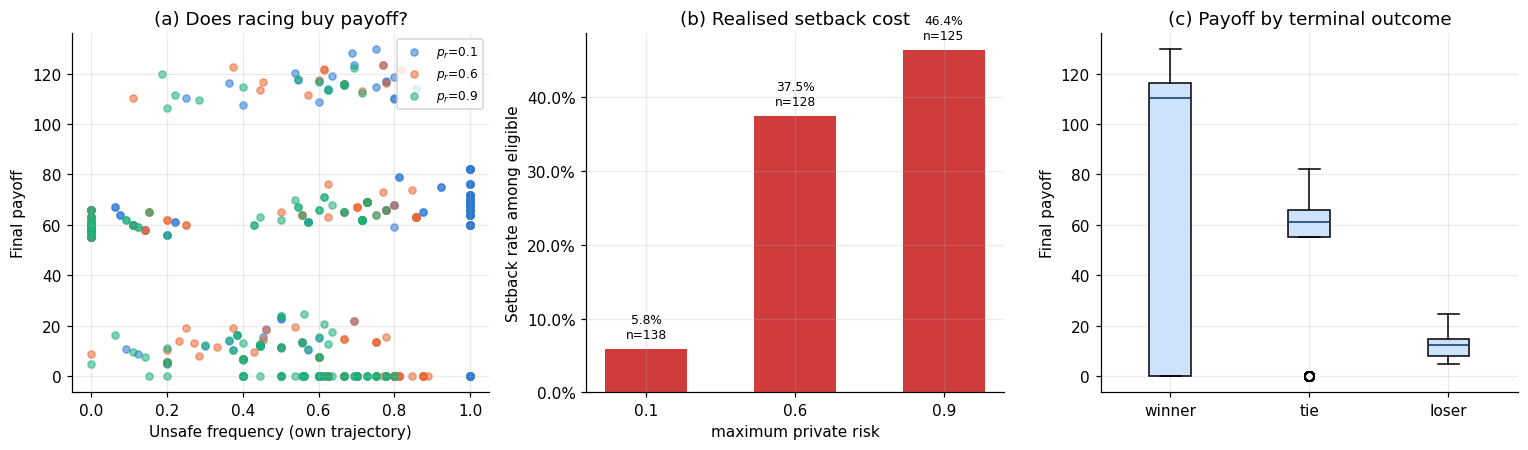

Correlation between own Unsafe frequency and own final payoff, per risk treatment:
  p_r=0.1: r=+0.173 (p=0.029, n=160)
  p_r=0.6: r=-0.224 (p=0.004, n=160)
  p_r=0.9: r=-0.222 (p=0.005, n=160)

Tie rate across neutral player-races: 62.9%
  winner: setback rate 43.8% (n=89), mean payoff 65.3
  tie: setback rate 24.8% (n=302), mean payoff 48.3
  loser: setback rate 0.0% (n=89), mean payoff 12.4


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) does unsafe frequency buy payoff?
for i, (r, g) in enumerate(neutral_players.groupby("max_private_risk")):
    axes[0].scatter(g["unsafe_frequency"], g["final_payoff"], alpha=0.55, s=22,
                    label=f"$p_r$={r}", color=COLOR_MODEL[i % len(COLOR_MODEL)])
axes[0].set_xlabel("Unsafe frequency (own trajectory)")
axes[0].set_ylabel("Final payoff")
axes[0].set_title("(a) Does racing buy payoff?")
axes[0].legend(fontsize=8)

# (b) setback rate among the eligible, by risk
elig = neutral_players[neutral_players["setback_eligible"] == 1] if "setback_eligible" in neutral_players.columns else neutral_players
sb = elig.groupby("max_private_risk")["setback"].agg(["mean", "size"])
axes[1].bar(sb.index.astype(str), sb["mean"], color=COLOR_UNSAFE, width=0.55)
for i, (k, r) in enumerate(sb.iterrows()):
    axes[1].text(i, r["mean"] + 0.015, f"{r['mean']:.1%}\nn={int(r['size'])}", ha="center", fontsize=8)
axes[1].set_xlabel("maximum private risk")
axes[1].set_ylabel("Setback rate among eligible")
axes[1].set_title("(b) Realised setback cost")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# (c) payoff by outcome
box_data = [neutral_players.loc[neutral_players.outcome == o, "final_payoff"].values
            for o in ["winner", "tie", "loser"] if (neutral_players.outcome == o).any()]
labels = [o for o in ["winner", "tie", "loser"] if (neutral_players.outcome == o).any()]
axes[2].boxplot(box_data, labels=labels, patch_artist=True,
                boxprops=dict(facecolor="#cde2fb"), medianprops=dict(color="#0d366b"))
axes[2].set_ylabel("Final payoff")
axes[2].set_title("(c) Payoff by terminal outcome")

plt.tight_layout()
plt.show()

from scipy.stats import pearsonr
print("Correlation between own Unsafe frequency and own final payoff, per risk treatment:")
for r, g in neutral_players.groupby("max_private_risk"):
    if g["unsafe_frequency"].nunique() > 1:
        rho, p = pearsonr(g["unsafe_frequency"], g["final_payoff"])
        print(f"  p_r={r}: r={rho:+.3f} (p={p:.3f}, n={len(g)})")
print()
tie_rate = (neutral_players["outcome"] == "tie").mean()
print(f"Tie rate across neutral player-races: {tie_rate:.1%}")
if "setback_eligible" in neutral_players.columns:
    for o in ["winner", "tie", "loser"]:
        g = neutral_players[neutral_players.outcome == o]
        if len(g):
            print(f"  {o}: setback rate {g['setback'].mean():.1%} (n={len(g)}), "
                  f"mean payoff {g['final_payoff'].mean():.1f}")


**What this section establishes.**

*Information.* Within a risk treatment, racing more does **not** buy payoff -- and at the two
higher risk levels it actively costs:

| treatment | corr(own Unsafe frequency, own final payoff) | n |
|---|---|---|
| p_r = 0.1 | **+0.173** (p = 0.029) | 160 |
| p_r = 0.6 | **-0.224** (p = 0.004) | 160 |
| p_r = 0.9 | **-0.222** (p = 0.005) | 160 |

Only in the near-harmless 0.1 treatment does racing pay at all, and weakly. Once private risk is
substantive the correlation is significantly **negative**: the players that raced hardest earned
*less*.

*Knowledge -- a collective-action trap, with every piece visible in the data.*

- **Racing is individually counterproductive** wherever risk actually bites, by the game's own
  scoring, with no appeal to social welfare needed.
- **Winning is what gets punished.** Setback eligibility is winner-only by construction, so
  winners carry a 43.8% setback rate against 24.8% for ties and 0% for losers -- a literal
  winner's curse written into the mechanism.
- **Symmetry means almost nobody wins.** The tie rate is 62.9%: both seats run near-identical
  policies, so races usually end level and the prize is split. The Unsafe choice meant to buy a
  decisive lead mostly buys accumulated risk that both sides carry to a shared finish.

Stated precisely: **the behavior is individually unprofitable under real risk, collectively
costly, and still overwhelmingly chosen.** Sections 4-4c explain why it is chosen (framing and
opponent type dominate the incentive signal); Section 5 explains why it persists once started,
for the Gemini family at least (behind -> Unsafe; opponent Unsafe -> Unsafe). Section 7 rules
out the benign reading that agents simply failed to do the arithmetic -- improving payoff
comprehension *increases* Unsafe.

WARNING -- setback is a stochastic draw and these cells are small, so setback *rates* are noisy
even where the ordering is structural. Winner-only eligibility is a mechanism fact, not an
estimate. The correlations above pool models with very different base rates; per-model splits
are in the tables above.


## 5. Prompt-surface sensitivity (open-weight, qwen)

This lane's raw per-decision logs aren't retained in `results/open_source/` (see
`results/README.md`); the admitted artifact is `variant_summary.csv`, which already carries
cluster-bootstrap 95% CIs per variant. We use it as-is, but plot every variant with its
interval rather than quoting only the extremes.


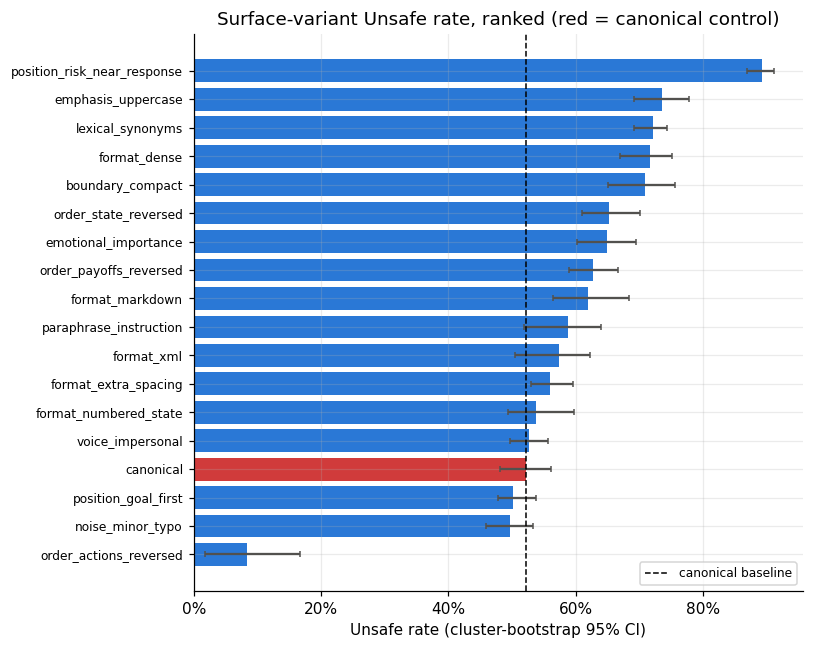

Span across 18 surface variants: 80.8% (order_actions_reversed=8.4% to position_risk_near_response=89.2%), canonical baseline=52.2%.
0 / 18 variants have a 95% CI wider than 15pp — a reminder this is a single-model, n=30-races-per-variant pilot.


In [23]:
surface = pd.read_csv(REPO / "results" / "open_source" / "surface_sensitivity_pilot" / "variant_summary.csv")
surface_sorted = surface.sort_values("unsafe_rate").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
y = np.arange(len(surface_sorted))
colors = [COLOR_UNSAFE if v == "control" else "#2a78d6" for v in surface_sorted["interpretation"]]
ax.barh(y, surface_sorted["unsafe_rate"],
        xerr=[surface_sorted["unsafe_rate"] - surface_sorted["unsafe_rate_cluster_bootstrap_ci95_low"],
              surface_sorted["unsafe_rate_cluster_bootstrap_ci95_high"] - surface_sorted["unsafe_rate"]],
        color=colors, ecolor="#52514e", capsize=2)
ax.set_yticks(y)
ax.set_yticklabels(surface_sorted["variant"], fontsize=8)
ax.set_xlabel("Unsafe rate (cluster-bootstrap 95% CI)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axvline(surface.loc[surface.variant == "canonical", "unsafe_rate"].iloc[0], color="black", ls="--", lw=1, label="canonical baseline")
ax.set_title("Surface-variant Unsafe rate, ranked (red = canonical control)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

span = surface_sorted["unsafe_rate"].max() - surface_sorted["unsafe_rate"].min()
baseline_rate = surface.loc[surface.variant == "canonical", "unsafe_rate"].iloc[0]
print(f"Span across {len(surface_sorted)} surface variants: {span:.1%} "
      f"({surface_sorted.iloc[0]['variant']}={surface_sorted.iloc[0]['unsafe_rate']:.1%} to "
      f"{surface_sorted.iloc[-1]['variant']}={surface_sorted.iloc[-1]['unsafe_rate']:.1%}), "
      f"canonical baseline={baseline_rate:.1%}.")
n_wide_ci = (surface["unsafe_rate_cluster_bootstrap_ci95_high"] - surface["unsafe_rate_cluster_bootstrap_ci95_low"] > 0.15).sum()
print(f"{n_wide_ci} / {len(surface)} variants have a 95% CI wider than 15pp — a reminder this is a single-model, n=30-races-per-variant pilot.")


## 6. Does understanding the payoff structure change behavior?

`game_understanding_pilot` pairs two things on the *same* qwen model: (a) semantic-accuracy
probes on the game's payoff/state rules, with and without a calculator decision-card aid, and
(b) actual race behavior, with and without that same aid. Both are loaded raw below — no
numbers are pre-typed.


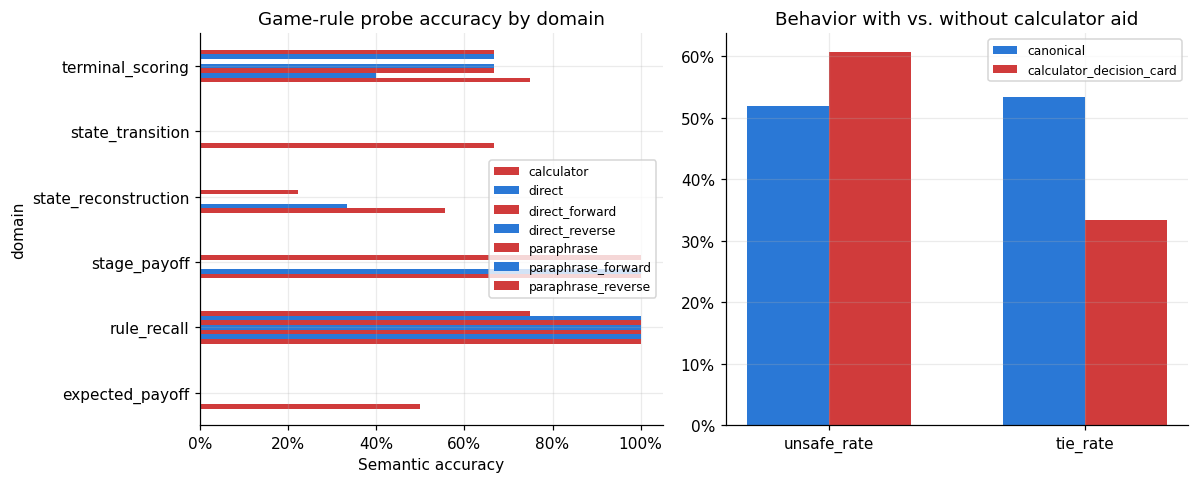

Unaided semantic accuracy: 52.1%
With calculator aid: 75.6%  (+23.5%)
Unsafe rate without aid: 52.0% -> with aid: 60.8%  (+8.8%)

Authors' own claim boundary (admission.json):
  Probe accuracy supports rule/arithmetic performance under the tested prompt pool. It does not establish an internal world model. Calculator accuracy measures use of disclosed outputs, not unaided comprehension.


In [24]:
gu_dir = REPO / "results" / "open_source" / "game_understanding_pilot"
probe_summary = pd.read_csv(gu_dir / "probe_summary.csv")
behavior_summary = pd.read_csv(gu_dir / "behavior_summary.csv")
admission = json.loads((gu_dir / "admission.json").read_text(encoding="utf-8"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

domain_probe = probe_summary[probe_summary.domain != "ALL"]
pivot = domain_probe.pivot(index="domain", columns="condition", values="semantic_accuracy")
pivot.plot.barh(ax=axes[0], color=[COLOR_UNSAFE, "#2a78d6"])
axes[0].set_xlabel("Semantic accuracy")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Game-rule probe accuracy by domain")
axes[0].legend(fontsize=8)

metrics = ["unsafe_rate", "tie_rate"]
x = np.arange(len(metrics))
width = 0.32
for i, cond in enumerate(behavior_summary["condition"]):
    vals = behavior_summary.loc[behavior_summary.condition == cond, metrics].iloc[0].values.astype(float)
    axes[1].bar(x + i * width, vals, width, label=cond, color=["#2a78d6", COLOR_UNSAFE][i])
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(metrics)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Behavior with vs. without calculator aid")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

acc_gain = admission["probe_calculator_semantic_accuracy"] - admission["probe_unaided_semantic_accuracy"]
unsafe_before = behavior_summary.loc[behavior_summary.condition == "canonical", "unsafe_rate"].iloc[0]
unsafe_after = behavior_summary.loc[behavior_summary.condition == "calculator_decision_card", "unsafe_rate"].iloc[0]
print(f"Unaided semantic accuracy: {admission['probe_unaided_semantic_accuracy']:.1%}")
print(f"With calculator aid: {admission['probe_calculator_semantic_accuracy']:.1%}  (+{acc_gain:.1%})")
print(f"Unsafe rate without aid: {unsafe_before:.1%} -> with aid: {unsafe_after:.1%}  ({unsafe_after - unsafe_before:+.1%})")
print()
print("Authors' own claim boundary (admission.json):")
print(" ", admission["claim_boundary"])


**Reading this section:** better arithmetic/rule accuracy about payoffs coincides with *more*
Unsafe choices and *fewer* ties, not fewer Unsafe choices — consistent with Unsafe being the
locally rational move once the payoff structure is correctly parsed, not a mistake that
disappears with comprehension. The claim-boundary text above is printed verbatim because it is
the load-bearing caveat: this measures rule/arithmetic performance under the tested prompt
pool, not an internal world model, and the calculator condition measures use of *disclosed*
outputs, not unaided comprehension.


## 7. N-player extension (qwen2.5-14b-instruct, N=3)

A structurally different mechanism (3 simultaneous players instead of 2) run on the same
open-weight model family. Loaded from `players.csv`/`races.csv` directly since this schema
doesn't fit the 2-player analyzer.


In [25]:
def load_nplayer(root_name, risk_glob_prefix):
    root = REPO / "results" / "nplayer" / root_name / "qwen2.5-14b-instruct"
    rows = []
    for run_dir in sorted(root.glob(f"{risk_glob_prefix}*")):
        races_path = run_dir / "races.csv"
        if not races_path.exists():
            continue
        races = pd.read_csv(races_path)
        races["run_dir"] = run_dir.name
        rows.append(races)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

nplayer_baseline = load_nplayer("nplayer_nonpersona", "baseline_nplayer")
nplayer_riskaware = load_nplayer("nplayer-riskaware", "persona_nplayer_baseline_risk")

print("baseline dirs:", nplayer_baseline["run_dir"].unique().tolist() if len(nplayer_baseline) else "none")
print("risk-aware persona dirs:", nplayer_riskaware["run_dir"].unique().tolist() if len(nplayer_riskaware) else "none")
print()
print(f"n races: baseline={len(nplayer_baseline)}, risk-aware persona sweep={len(nplayer_riskaware)}")
if len(nplayer_riskaware):
    per_cell = nplayer_riskaware.groupby("run_dir").size()
    print("races per risk cell (risk-aware sweep):")
    print(per_cell)


baseline dirs: ['baseline_nplayer_n3']
risk-aware persona dirs: ['persona_nplayer_baseline_risk_1_n3', 'persona_nplayer_baseline_risk_2_n3', 'persona_nplayer_baseline_risk_3_n3', 'persona_nplayer_baseline_risk_4_n3', 'persona_nplayer_baseline_risk_5_n3', 'persona_nplayer_baseline_risk_6_n3']

n races: baseline=60, risk-aware persona sweep=36
races per risk cell (risk-aware sweep):
run_dir
persona_nplayer_baseline_risk_1_n3    6
persona_nplayer_baseline_risk_2_n3    6
persona_nplayer_baseline_risk_3_n3    6
persona_nplayer_baseline_risk_4_n3    6
persona_nplayer_baseline_risk_5_n3    6
persona_nplayer_baseline_risk_6_n3    6
dtype: int64


In [26]:
players_path = REPO / "results" / "nplayer" / "nplayer_nonpersona" / "qwen2.5-14b-instruct" / "baseline_nplayer_n3" / "players.csv"
if players_path.exists():
    nplayer_players = pd.read_csv(players_path)
    print(nplayer_players.columns.tolist())
    risk_col = "max_private_risk" if "max_private_risk" in nplayer_players.columns else \
               [c for c in nplayer_players.columns if "risk" in c.lower()][0]
    unsafe_col = [c for c in nplayer_players.columns if "unsafe" in c.lower() and "freq" in c.lower()]
    unsafe_col = unsafe_col[0] if unsafe_col else [c for c in nplayer_players.columns if "unsafe" in c.lower()][0]
    by_risk = nplayer_players.groupby(risk_col)[unsafe_col].agg(["mean", "size"])
    print(by_risk)
else:
    print("players.csv not found at expected path — check results/nplayer layout")


['game_id', 'model', 'n_players', 'max_private_risk', 'prompt_version', 'run_phase', 'persona_condition', 'persona_role', 'rep', 'game_seed', 'n_rounds', 'player', 'player_index', 'others', 'outcome', 'progress', 'stage_payoff', 'unsafe_count', 'unsafe_frequency', 'private_risk', 'prize', 'setback_eligible', 'setback_draw', 'setback', 'final_payoff']
                      mean  size
max_private_risk                
0.1               0.708773    60
0.6               0.598374    60
0.9               0.489800    60


**Reading this section:** the same risk-decreasing direction shows up with 3 simultaneous
players. Cell sizes here are small (print output above) — the repo's own
`results/nplayer/rigorous_analysis.py` flags cells this size as underpowered for inference.
Use this as a second, structurally-different pilot signal pointing the same direction as
Sections 3–4, not as an independent confirmatory result.


## 8. Synthesis

Everything below is read out of variables computed above — nothing retyped.


In [27]:
synthesis_rows = []

obs_09 = model_risk_summary.loc[model_risk_summary["max_private_risk"] == 0.9, "mean_unsafe_rate"].mean()
synthesis_rows.append({
    "finding": "Unsafe rate at p_r=0.9 vs. theory equilibrium (Gemini baseline)",
    "effect_size": f"{obs_09:.1%} observed vs {theory_wide.loc[0.9,'reference']:.1%} predicted "
                   f"({obs_09 - theory_wide.loc[0.9,'reference']:+.1%})",
    "n": f"{baseline_turns['game_id'].nunique()} races / {len(baseline_turns)} decisions",
    "caveat": "Direction matches theory, magnitude does not. best_fit parameter point narrows "
              "the gap only slightly. Pilot phase.",
})

top_persona = span_df.loc[span_df["persona_span"].idxmax()]
synthesis_rows.append({
    "finding": f"Persona span, risk-seeking vs risk-averse ({top_persona['model']})",
    "effect_size": f"{top_persona['persona_span']:+.1%}",
    "n": f"{int(stance_summary['n_races'].sum())} races across both models",
    "caveat": "Exceeds the same model's full 0.1->0.9 risk-treatment span; prompt hash "
              "unchanged between conditions. Pilot phase.",
})

synthesis_rows.append({
    "finding": "Prompt-surface variant span (open-weight qwen)",
    "effect_size": f"{span:.1%}",
    "n": f"{len(surface_sorted)} variants x {int(surface_sorted['n_decisions'].iloc[0])} decisions each",
    "caveat": f"{n_wide_ci}/{len(surface)} variants have bootstrap CIs wider than 15pp.",
})

synthesis_rows.append({
    "finding": "Unsafe-rate shift when a calculator aid raises payoff comprehension",
    "effect_size": f"{unsafe_after - unsafe_before:+.1%} Unsafe (accuracy {acc_gain:+.1%})",
    "n": "30 races/condition, 558 decisions/condition",
    "caveat": admission["claim_boundary"],
})

synthesis_df = pd.DataFrame(synthesis_rows)
pd.set_option("display.max_colwidth", 90)
display(synthesis_df)

print("\nProtocol status of every run feeding the tables above:")
print(inventory.loc[inventory["clean"], "run_phase"].value_counts(dropna=False).to_string())

,finding,effect_size,n,caveat
0,Unsafe rate at p_r=0.9 vs. theory equilibrium (Gemini baseline),62.1% observed vs 1.0% predicted (+61.2%),90 races / 1674 decisions,"Direction matches theory, magnitude does not. best_fit parameter point narrows the gap..."
1,"Persona span, risk-seeking vs risk-averse (gpt-5.4-nano)",+80.0%,180 races across both models,Exceeds the same model's full 0.1->0.9 risk-treatment span; prompt hash unchanged betw...
2,Prompt-surface variant span (open-weight qwen),80.8%,18 variants x 558 decisions each,0/18 variants have bootstrap CIs wider than 15pp.
3,Unsafe-rate shift when a calculator aid raises payoff comprehension,+8.8% Unsafe (accuracy +23.5%),"30 races/condition, 558 decisions/condition",Probe accuracy supports rule/arithmetic performance under the tested prompt pool. It d...



Protocol status of every run feeding the tables above:
run_phase
pilot    119


### Bottom line -- from data to information to knowledge

**Finding 1: every lever that does not change the incentives moves behavior more than the lever
that does.**

| Lever | Swing in Unsafe rate | Changes the game's incentives? |
|---|---|---|
| Private-risk treatment (0.1 -> 0.9), OpenAI models | 4.4 - 5.0 pp | **Yes** -- the designed manipulation |
| Own Eckel-Grossman risk persona (per ladder step) | 12.3 - 21.2 pp/step | No -- prompt hash unchanged |
| Persona stance (risk-seeking vs risk-averse) | 36 - 80 pp | No |
| Opponent's risk persona, Gemini (per step) | 15.1 pp/step | No -- not even about this agent |
| Prompt surface wording (18 variants) | 80.8 pp | No -- mostly meaning-preserving |
| Disclosed payoff arithmetic (calculator aid) | +8.8 pp | No -- payoffs were already stated |

In this mechanism, **Unsafe behavior is primarily a function of how the decision is presented
and who the agent is told it faces, and only secondarily of what the decision is worth.** The
`p_r`=0.9 equilibrium gap in Section 3 (+61.2 pp vs theory) is that same fact measured against
an absolute yardstick instead of against another condition.

**Finding 2: the personas are valid instruments, which is what makes Finding 1 damaging.** The
Eckel-Grossman ladder reproduces its intended ordering (Spearman +0.53 to +0.93). So the framing
sensitivity is not noise or prompt-parsing failure -- the models are reading the manipulation
correctly and weighting it above the incentive structure.

**Finding 3: risk contagion into cooperative agents replicates everywhere; escalation does not.**
Cooperative agents go more Unsafe against adversarial opponents in all three models and under
both persona instruments. But whether an *adversarial* agent escalates (Gemini, +52 pp) or backs
off (OpenAI, -9 to -12 pp) is provider-specific.

**Finding 4: there is no single "LLM agent" policy.** Section 5's replication table is the sharp
version: Gemini models go Unsafe in 100% of observations while behind and double their Unsafe
rate after an opponent defects; gpt-5.4-nano *inverts* the position effect and shows no
reciprocity at all. Same game, same prompt hash, same seed contract. **Pooling providers into a
single "LLM" row averages over qualitatively different policies**, and a single-provider result
should not be reported as a fact about LLM agents.

**Finding 5: racing is individually counterproductive, and comprehension does not fix it.**
corr(Unsafe frequency, final payoff) is significantly **negative** at `p_r`=0.6 and 0.9
(-0.224, -0.222); winners carry a 43.8% setback rate against 0% for losers; 62.9% of races end
tied. And when a calculator aid raises payoff-probe accuracy by 23.5 pp, Unsafe *rises* 8.8 pp
and ties fall from 53% to 33%. Unsafe is what these models do when they understand the payoffs
**better**, not worse -- which rules out the most benign available explanation.

**What this licenses, and what it does not.** It licenses: framing-sensitivity dominates
incentive-sensitivity in this mechanism; the risk-persona instrument has construct validity;
contagion into cooperators replicates; provider policies diverge. It does **not** license claims
about stable preferences, subjective understanding, or LLMs in general -- the `admission.json`
claim boundary printed in Section 7 is explicit that probe accuracy measures rule/arithmetic
performance under the tested prompt pool, not an internal world model.

**Required next step.** All 119 admitted runs are `run_phase="pilot"` (verified above), 6-30
races per cell. Per `CLAUDE.md` none of it may be pooled with or promoted to confirmatory
evidence. Two things follow for the confirmatory design:

1. **Power off the right effect.** The risk-treatment contrast is the *smallest and most
   fragile* effect in the entire set (4-5 pp on OpenAI models), while persona and surface effects
   are 10-20x larger. The current design implicitly assumes the opposite.
2. **Stratify by provider, never pool.** Finding 4 means a pooled confirmatory estimate would be
   an average over incompatible policies.

Two data-quality items must be resolved first, both listed in Section 1: the three
`frontier/persona/*_risk_matrix` directories whose manifests disagree with their `turns.jsonl`
row counts, and the five `running`/`failed` directories.
